# RetinAnalysis Tutorial : From Recording to Results

Here, we will walk through from looking at raw data to performing sanity checks and fundamental analyses on our electrophysiology data. We will discuss at which points we made certain *decision points* (mathemetical apporaches, etc.) and why. Afterwards, you can proceed to the more tailored demos that contain substantially less text descriptions. 

**Before running:**
- Docker Desktop is open and the `retinanalysis-database` container is running (see the README).
- The notebook kernel (top right) is `retinanalysis`.
- Run top to bottom. Each section only needs the ones before it.

## 0. Setup

In [1]:
import retinanalysis as ra
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Temporary: fixes garbage timecourses on Windows (visionloader double-array bug). Must run before any pipeline is built.
ra.patch_vision_double_array_bug()

C:\Users\Yasmine Tani\anaconda3\envs\retinanalysis\Lib\site-packages\datajoint\settings.py:992: UserWarning: No datajoint.json found. Using defaults and environment variables. Run `dj.config.save_template()` to create a template configuration.
  config = _create_config()


Patched visionloader's double-array '.params' field parsing (timecourses, etc.) to use a pure-Python fallback instead of the buggy compiled extension.


Optional: automatically save figures as editable SVG + PDF (for Illustrator) into `figures/`.

In [2]:
SAVE_CELLS = None  # 'all', a list of cell numbers e.g. [12, 15], or None = off. Cell numbers = the [n] left of each cell (stable after Kernel -> Restart & Run All).
ra.auto_save_figures(SAVE_CELLS, folder='figures')

Automatic figure saving is OFF.


## 1. Finding your data and stimuli

**How a recording is organized.** In Symphony, one retina (an *experiment*, e.g. `20251016A`) is recorded in *groups*, usually one per light level (NDF 5 → NDF 0). Each protocol run inside a group is saved as its own *datafile* (`data016`, `data017`, …). Spike sorting (Kilosort) is done per *chunk* of datafiles, so the same physical cell can get **different cell IDs in different chunks**.

**What each piece gives you:**
- The **SpatialNoise (white noise) run** gives STAs, i.e. receptive fields, and it's where cell types are assigned: the `.classificationXX.txt` files (`YT`, `JK`, `ag`, … = whoever classified). In code this is the `AnalysisChunk`.
- A **protocol run** (gratings, flashes, …) gives the responses you want to analyze: `StimBlock` (what was shown) + `ResponseBlock` (spikes).
- A **pipeline** (`ra.create_mea_pipeline`) bundles one protocol datafile with a reference noise chunk and links their cell IDs by EI matching (section 3), so every responding cell gets a cell type and an RF.

This tutorial uses `20251016A`, a C57 wild-type retina that has SpatialNoise, ContrastResponseGrating, ContrastResponseFlash and GratingDSOS all at NDF 0. If it isn't in your database, `20251222A` (used by the contrast demos) works for sections 1–4.

In [3]:
EXP_NAME = '20251016A'

noise_search = ra.get_datasets_from_protocol_names('manookinlab.protocols.SpatialNoise', b_exact_match=True, verbose=False)
contrast_search = ra.get_datasets_from_protocol_names('contrast', verbose=False)
dsos_search = ra.get_datasets_from_protocol_names('manookinlab.protocols.GratingDSOS', b_exact_match=True, verbose=False)

this_exp = pd.concat([noise_search, contrast_search, dsos_search]).query('exp_name == @EXP_NAME')
if len(this_exp) == 0:
    raise ValueError(f'{EXP_NAME} is not in your database -- run ra.populate_database() or pick another exp_name.')
display(this_exp[['datafile_name', 'NDF', 'protocol_name', 'chunk_name']].drop_duplicates().sort_values('datafile_name'))

[2026-09-30 17:36:47] DataJoint 2.2.2 connected to root@127.0.0.1:3306


,datafile_name,NDF,protocol_name,chunk_name
76,data000,5.0,manookinlab.protocols.ContrastResponseGrating,data000
77,data001,5.0,manookinlab.protocols.ContrastResponseFlash,data001
69,data002,5.0,manookinlab.protocols.SpatialNoise,data002
78,data003,4.0,manookinlab.protocols.ContrastResponseGrating,data003
79,data004,4.0,manookinlab.protocols.ContrastResponseGrating,data004
80,data005,4.0,manookinlab.protocols.ContrastResponseFlash,data005
70,data006,4.0,manookinlab.protocols.SpatialNoise,data006
81,data007,3.0,manookinlab.protocols.ContrastResponseGrating,data007
71,data008,3.0,manookinlab.protocols.SpatialNoise,data008
82,data009,3.0,manookinlab.protocols.ContrastResponseFlash,data009


**Decision: which noise chunk and classification file to use for cell types.** `ra.find_classified_noise_chunk` prefers a classified chunk at NDF 0, then NDF 1, and prints what it found. If a chunk has several classification files, the one with `YT` in its name is used by default (`PREFERRED_TYPING_INITIALS` in `analysis_chunk.py`), otherwise the first one found, unless you name one with `TYPING_FILE`. Cell-type counts can differ between classifiers, so when comparing experiments, use the same classifier's files throughout and say which in the methods.

In [4]:
ANALYSIS_CHUNK = ra.find_classified_noise_chunk(EXP_NAME)   # or set by hand, e.g. 'data018'
TYPING_FILE = None                                            # e.g. 'data018.classificationYT.txt'; None = first found
print('Reference (typing) chunk:', ANALYSIS_CHUNK)

20251016A: using data018 (NDF 0, classification file(s): ['data018.classificationag.txt', 'data018.classificationJK.txt', 'data018.classificationYT.txt']).
Reference (typing) chunk: data018


## 2. Cell types and receptive fields (white noise only)

Everything in this section comes from the noise chunk alone: no protocol run and no EI matching yet. Look at the mosaics first. If a type's RFs don't tile, or a cell's timecourse doesn't match its type, fix the classification before analyzing responses.

### RF shape: three views of the same STAs
- **Gaussian fit:** Vision fits a 2-D Gaussian to each STA (`SigmaX`, `SigmaY`, `Theta` in the `.params` file). Fast and compact, but only as good as the fit. Note: the ellipses are drawn with `std_scaling=1.6` passed as the ellipse's *width*, so each is drawn at a radius of 0.8 SD.
- **Contours:** traced from each cell's own STA (no fit) around its center. The map is lightly smoothed first (peak frame averaged with its neighbouring frames, blurred by under one stixel, traced on a 4× finer grid) so outlines aren't stixel staircases; `smooth=False` in `get_rf_contours` gives the raw version. With `contour_level='auto'`, the outline level is picked separately for each cell type as the level where that type's outlines tile best. The score is the uniformity index (Gauthier et al. 2009): the fraction of the mosaic covered by exactly one cell. A real mosaic tiles, so this avoids both piled-up blobs and gaps.
- **Portraits + timecourses:** each cell's raw STA pixels, with its timecourse (red) over its type's mean (blue). This is QC: a cell whose timecourse doesn't match its type (`r` below 0.8, red frame) may be misclassified or bad.

In [5]:
with ra.scrollable_prints():
    noise_chunk = ra.AnalysisChunk(EXP_NAME, ANALYSIS_CHUNK)   # STAs, RF fits, cell types
print(f'{ANALYSIS_CHUNK}: {len(noise_chunk.cell_ids)} cells | typing files: {noise_chunk.typing_files}')


data018: 512 cells | typing files: ['data018.classificationYT.txt', 'data018.classificationag.txt', 'data018.classificationJK.txt']


off/brisk sustained: contour level 0.45 (uniformity index 0.44)
off/brisk transient: contour level 0.50 (uniformity index 0.60)
off/transient: contour level 0.45 (uniformity index 0.55)
on/brisk sustained: contour level 0.75 (uniformity index 0.55)
on/brisk transient: contour level 0.65 (uniformity index 0.62)


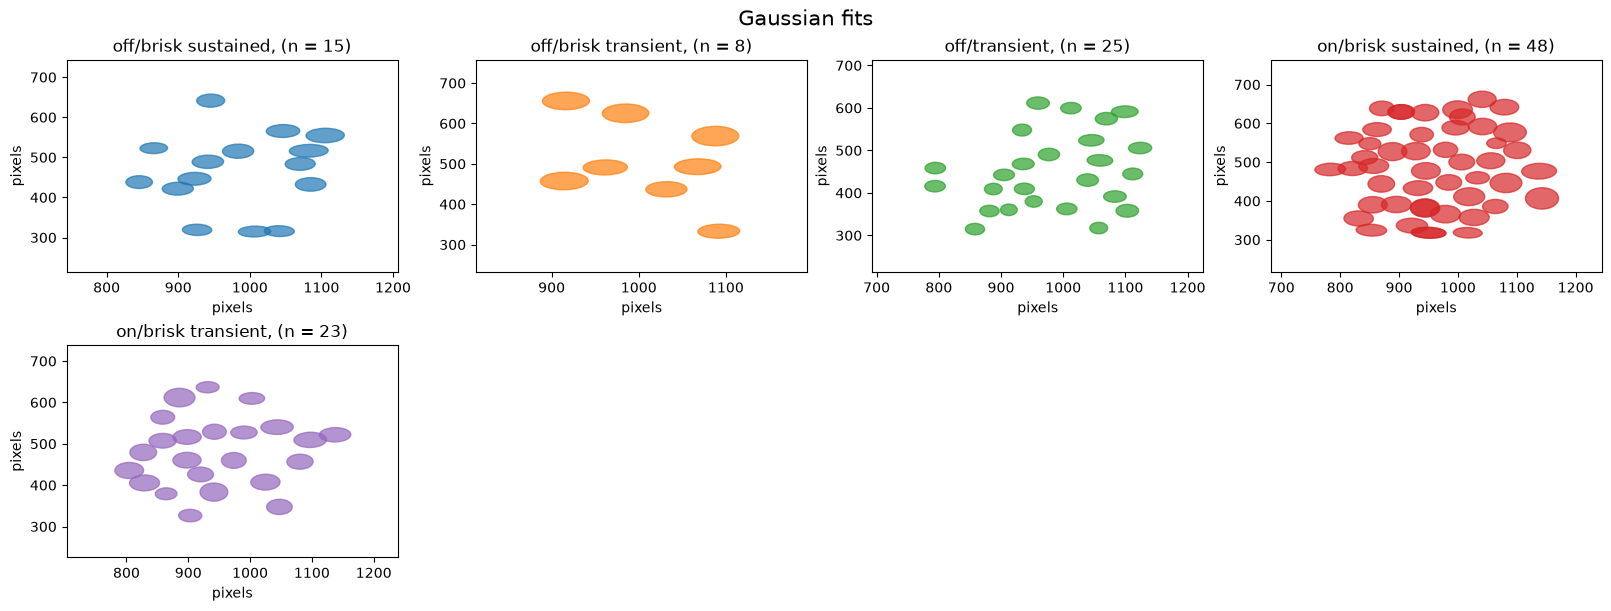

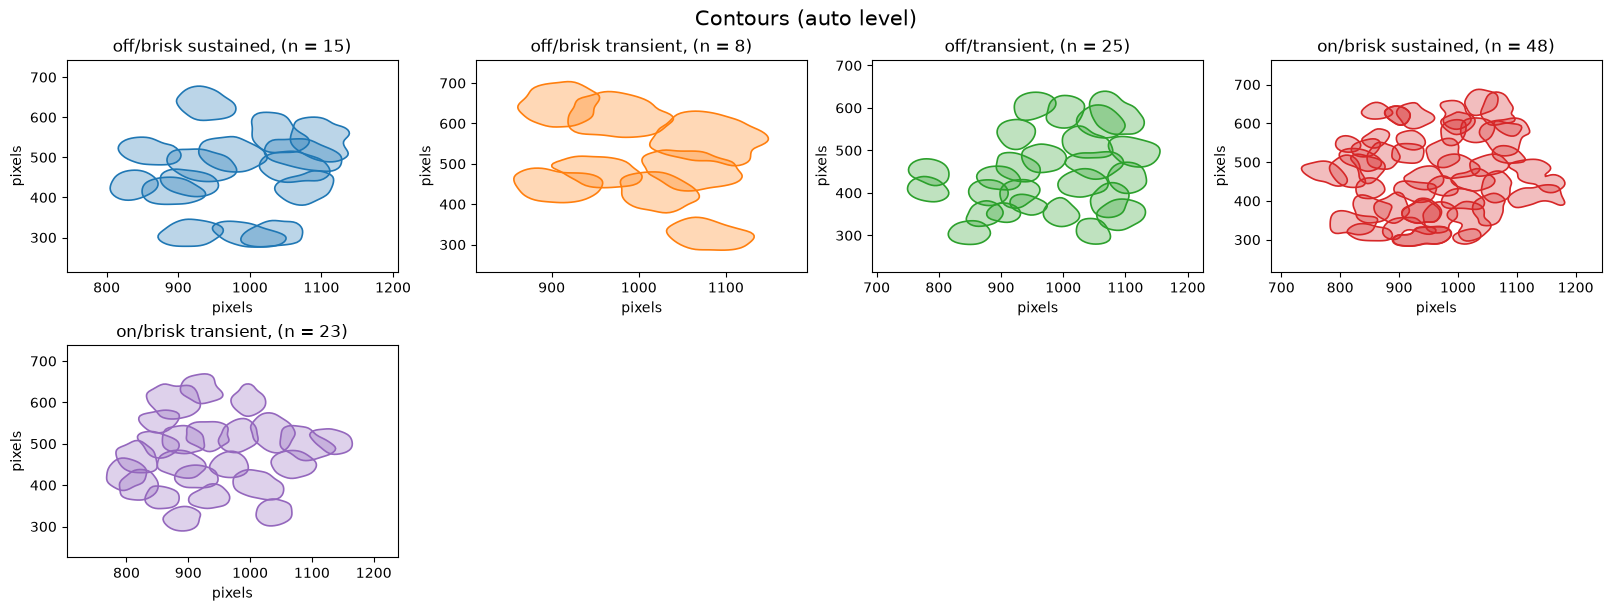

In [6]:
rfs_gauss = noise_chunk.plot_rfs(minimum_n=3, b_zoom=True, typing_file=TYPING_FILE, title='Gaussian fits')
rfs_contour = noise_chunk.plot_rfs(minimum_n=3, b_zoom=True, typing_file=TYPING_FILE,
                                               use_contours=True, contour_level='auto', title='Contours (auto level)')

off/brisk sustained: no cells with timecourse r < 0.8
off/brisk transient: no cells with timecourse r < 0.8
off/transient: no cells with timecourse r < 0.8
on/brisk sustained: no cells with timecourse r < 0.8
on/brisk transient: no cells with timecourse r < 0.8


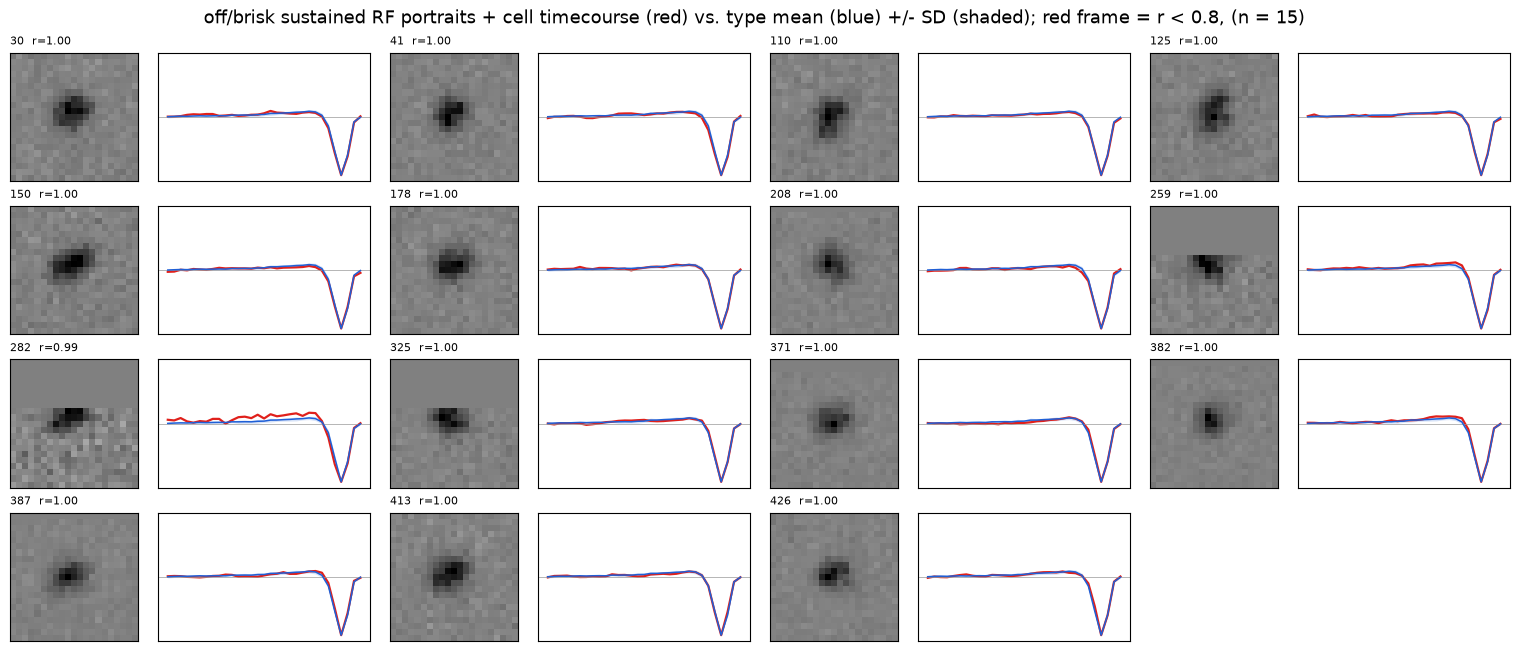

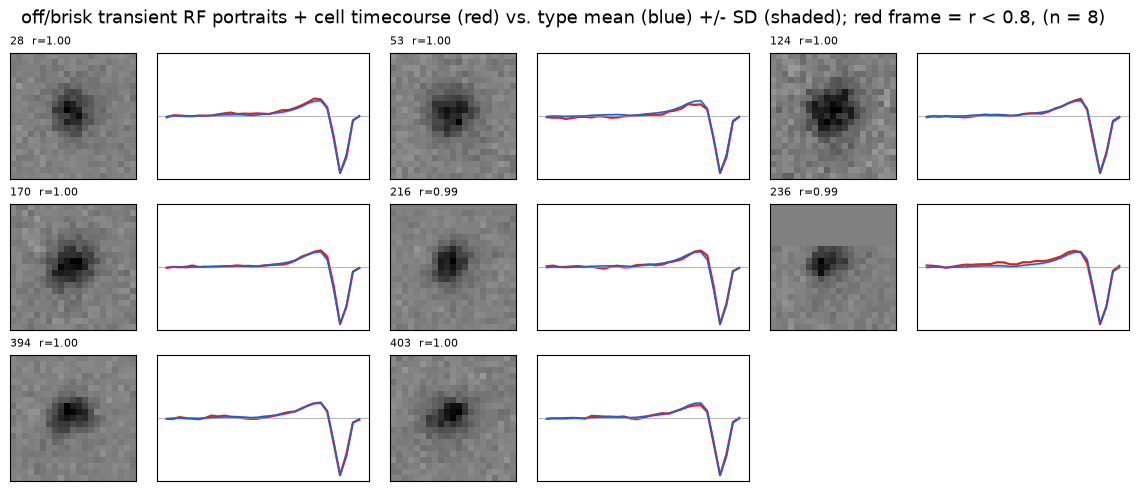

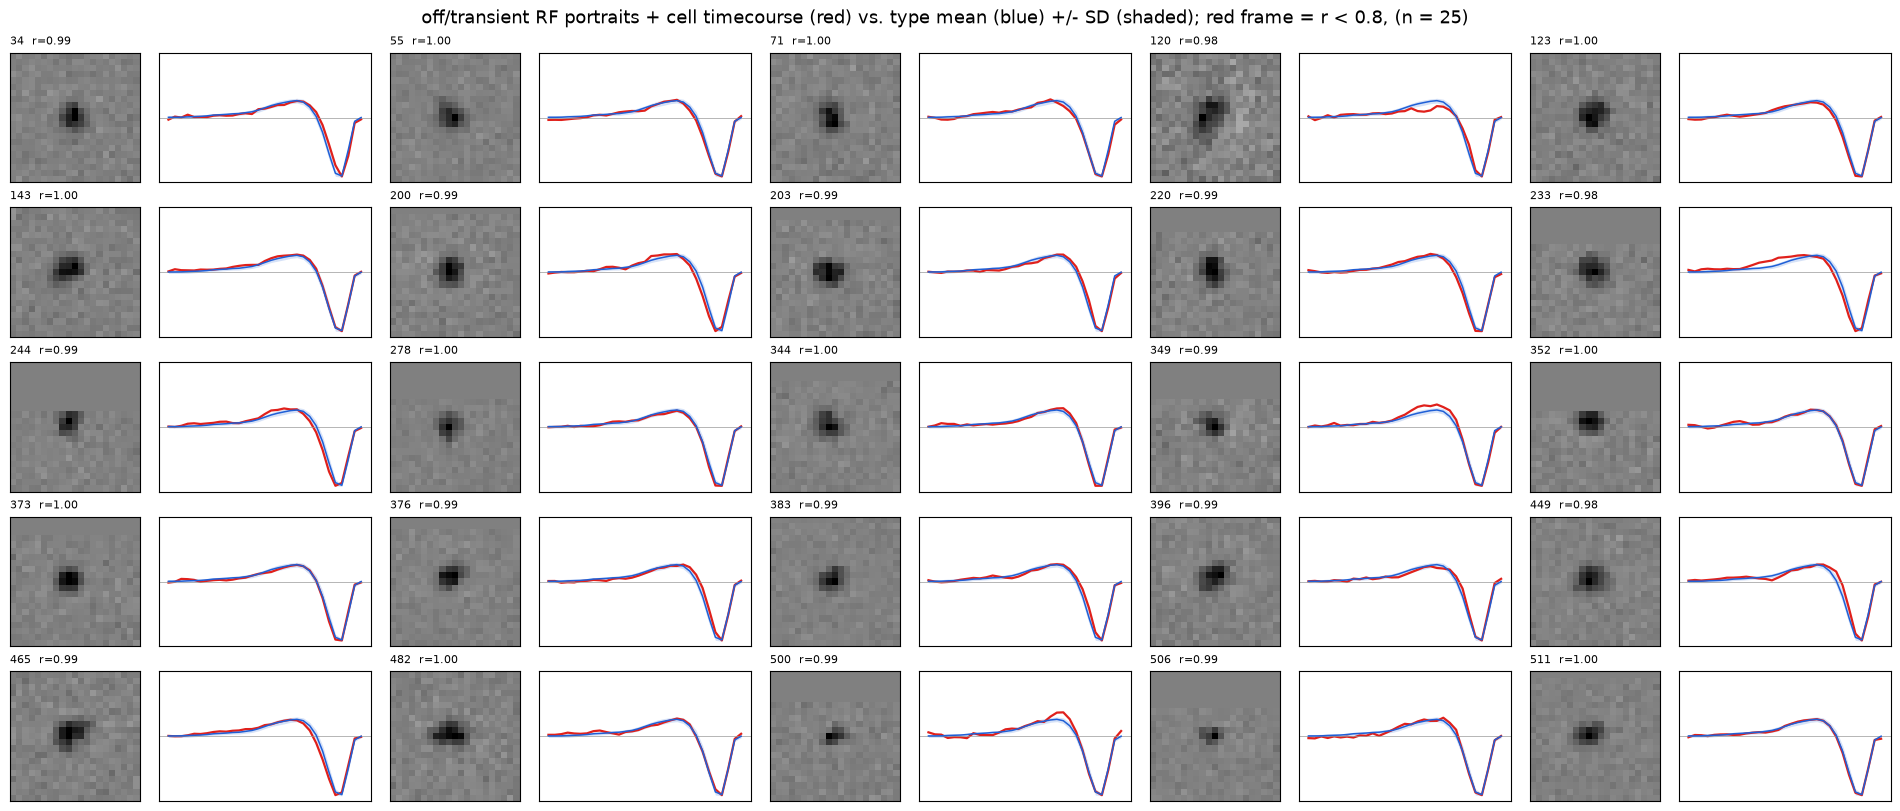

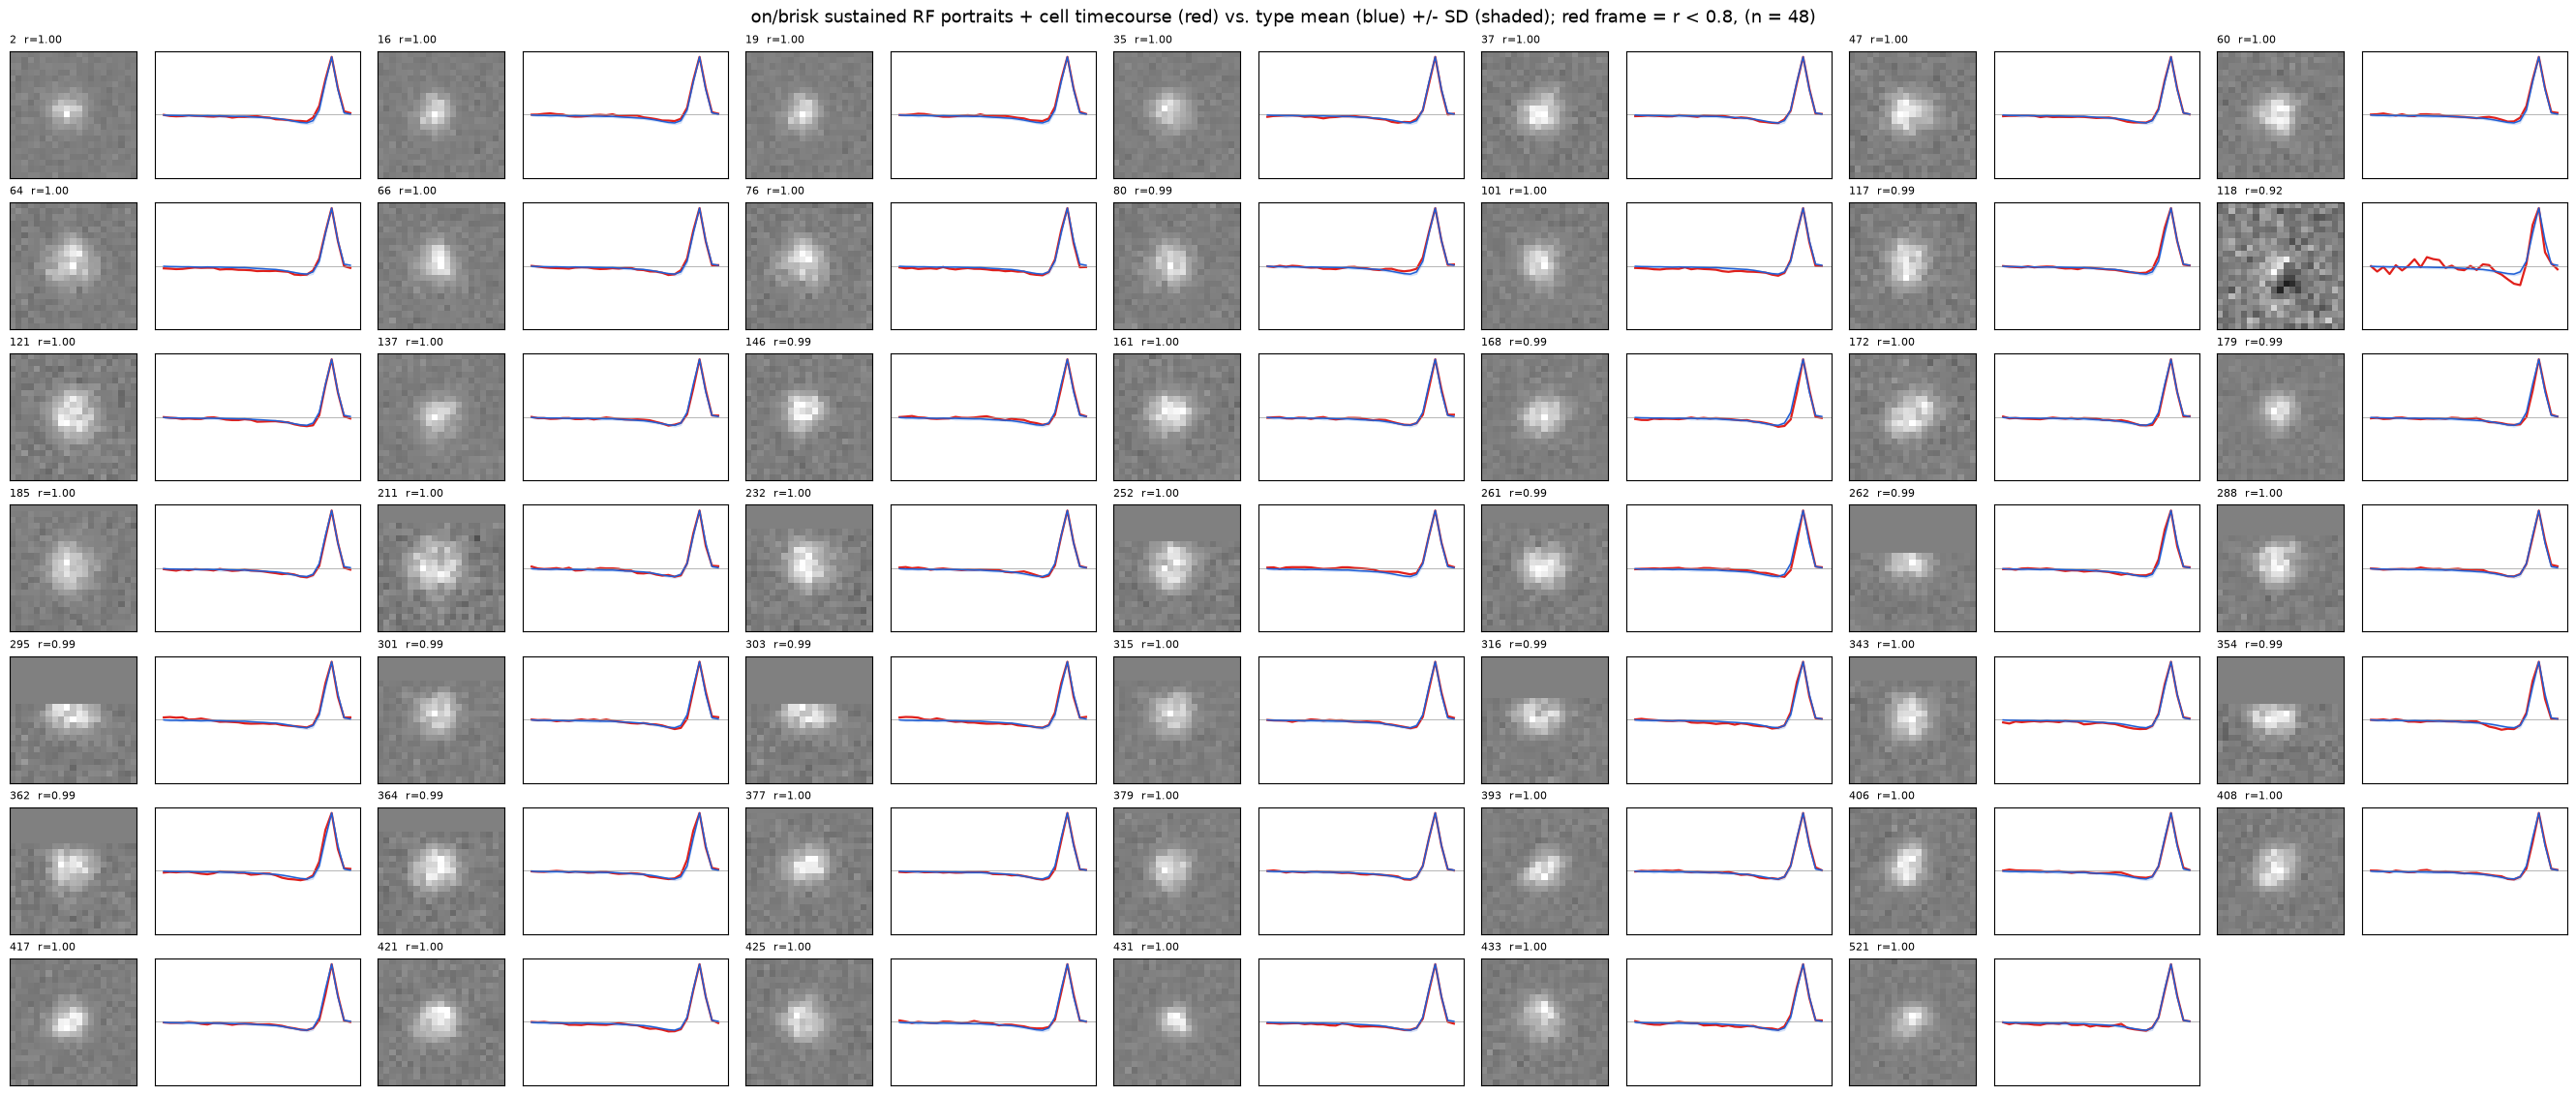

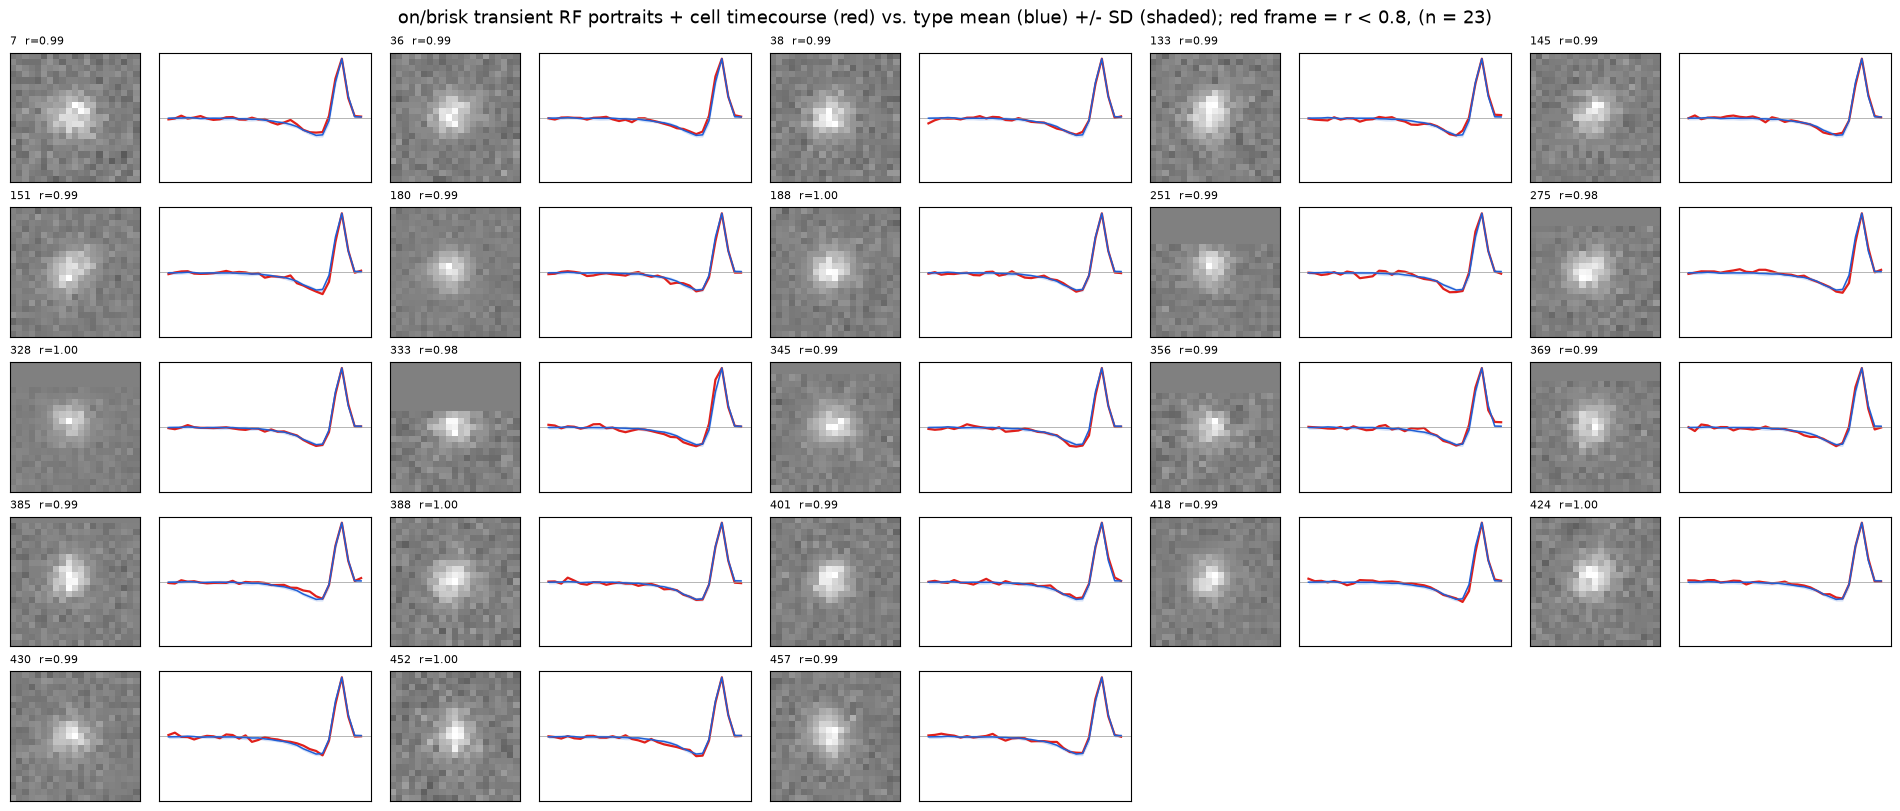

In [7]:
PORTRAIT_TYPE = None   # e.g. 'off/brisk sustained'; None = every type with >= 3 cells
portraits = noise_chunk.plot_rf_portraits(cell_types=PORTRAIT_TYPE, minimum_n=3, typing_file=TYPING_FILE,
                                                      with_timecourses=True, tc_flag_r=0.8)

## 3. Linking runs: EI matching

**Why it's needed.** Because each chunk is sorted separately, cell 212 in the grating run isn't necessarily cell 212 in the noise run. To give a grating-responding cell its cell type and RF, we find its partner in the noise chunk.

**How.** Each cell has an *electrical image* (EI): its average spike waveform on every electrode, a fingerprint of where it sits on the array. `ra.cluster_match` correlates every protocol cell's EI with every noise cell's EI three ways (full waveform, spatial footprint, power per electrode). It accepts a pair only if:
- they're each other's best match,
- the best match clearly beats the second best (the runner-up must be under 90% of it),
- the correlation clears `corr_cutoff`.

Cells that fail any of these are left out as `Unmatched`, not guessed.

**Decision: `corr_cutoff = 0.85`.** That's the lab convention, carried over from the MATLAB code. Note that `ra.create_mea_pipeline` defaults to **0.8** if you don't pass it, so always pass it explicitly. Higher = fewer but safer matches.

data016: 471 cells | data018: 512 cells | matched at 0.85: 184 (39% of the smaller run)


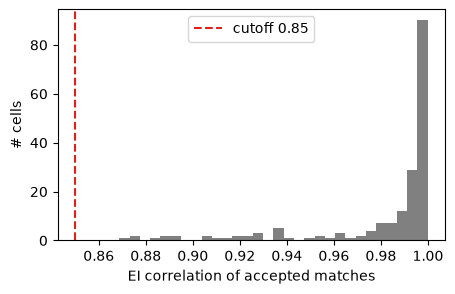

In [8]:
CORR_CUTOFF = 0.85
GRATING_PROTOCOL = 'manookinlab.protocols.ContrastResponseGrating'

grating_datafile = ra.get_ndf_blocks_for_protocol(EXP_NAME, GRATING_PROTOCOL, verbose=False).query('NDF == 0')['datafile_name'].iloc[0]
with ra.scrollable_prints():
    pipeline = ra.create_mea_pipeline(EXP_NAME, grating_datafile, analysis_chunk_name=ANALYSIS_CHUNK,
                                      typing_file=TYPING_FILE, corr_cutoff=CORR_CUTOFF)

n_protocol, n_noise, n_matched = len(pipeline.resp.cell_ids), len(pipeline.analysis_chunk.cell_ids), len(pipeline.match_dict)
print(f'{grating_datafile}: {n_protocol} cells | {ANALYSIS_CHUNK}: {n_noise} cells | matched at {CORR_CUTOFF}: {n_matched} '
      f'({100 * n_matched / min(n_protocol, n_noise):.0f}% of the smaller run)')

corrs = np.array(list(pipeline.corr_dict.values()))
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(corrs, bins=30, color='0.5')
ax.axvline(CORR_CUTOFF, color='#e0201b', ls='--', label=f'cutoff {CORR_CUTOFF}')
ax.set_xlabel('EI correlation of accepted matches'); ax.set_ylabel('# cells'); ax.legend()
plt.show()

**How much does the cutoff matter here?** Re-run the matcher at 0.80 on the same two runs. The difference is the pairs that sit between 0.80 and 0.85: the ones a looser cutoff would let in.

In [9]:
loose_matches, loose_corrs = ra.cluster_match(pipeline.analysis_chunk, pipeline.resp, corr_cutoff=0.80, verbose=False)
print(f'0.80: {len(loose_matches)} matches | 0.85: {n_matched} matches | extra at 0.80: {len(loose_matches) - n_matched}')

0.80: 191 matches | 0.85: 184 matches | extra at 0.80: 7


**Check it: the different-retina negative control.** Match this experiment's noise chunk against a chunk from a *different* retina. No cell can truly match, so every accepted pair is a false match. It should be ~0; if it isn't, the cutoff isn't safe for this kind of run. Run this whenever you join a new kind of run. For example, flash runs' EIs gave a few false matches even at 0.85 when we tried joining them to gratings.

In [10]:
OTHER_EXP, OTHER_CHUNK = '20260506A', 'data006'   # any chunk from a different retina in your database

with ra.scrollable_prints():
    other_chunk = ra.AnalysisChunk(OTHER_EXP, OTHER_CHUNK, b_load_spatial_maps=False)
false_matches, false_corrs = ra.cluster_match(pipeline.analysis_chunk, other_chunk, corr_cutoff=CORR_CUTOFF, verbose=False)
print(f'{EXP_NAME} {ANALYSIS_CHUNK} vs {OTHER_EXP} {OTHER_CHUNK}: {len(false_matches)} matches at {CORR_CUTOFF} (should be ~0)')

20251016A data018 vs 20260506A data006: 22 matches at 0.85 (should be ~0)


## 4. Analysis: contrast-response curves (ContrastResponseGrating)

### The stimulus: ContrastResponseGrating

On every trial the screen shows an achromatic **drifting sinusoidal grating** on a mean-gray background (intensity 0.5). Between trials the screen is plain gray. Only the grating's contrast changes from trial to trial. Typical settings, taken from 20251016A (the cell below prints your experiment's own values):

- **Timing per trial:** 250 ms gray (`preTime`), then 4000 ms of grating (`stimTime`), then 750 ms gray (`tailTime`).
- **Drift:** 2 Hz (`temporalFrequency`), so each 4 s trial holds 8 light/dark cycles passing over the cell.
- **Spatial:** `barWidth` 300 µm, orientation 0°. Whether `barWidth` is half a cycle or a full cycle is set by the Symphony protocol code, which isn't in this repo; check it before quoting a spatial frequency.
- **Contrast:** 10 levels, 0, 0.01, 0.02, 0.04, 0.08, 0.16, 0.24, 0.32, 0.64 and 0.96, with 8 repeats each. Contrast is Michelson contrast: the sine wave swings from `mean × (1 − c)` to `mean × (1 + c)`.
- **The 0% trials** are a gray screen for the full trial length. That makes them a blank control measured over exactly the same window as every other contrast.
- **Light level:** the protocol is run once per NDF. `load_contrast_section` picks the NDF 0 run by default (`default_ndf=0`) and prints which datafile it used.


### What number is "the response"?

- **Mean rate** (spikes in the stimulus window ÷ its duration, Hz) works for any stimulus. It's the only option for **steps** (flashes, spots), which have no rhythm to lock to.
- **F1** is the size of the response at the grating's own temporal frequency, i.e. how strongly the cell's firing follows each light/dark cycle. For **drifting gratings** F1 catches responses that mean rate misses. A cell that fires to every bright bar and goes silent for every dark bar can have almost the same *mean* rate as at rest, but a large F1.

**Decision:** gratings → F1; flashes/spots → mean rate. `ra.build_trial_response_table` computes both for gratings, so you can compare.

### Baseline (noise subtraction)

Two conventions exist (`baseline_condition_key`):
- **Pre-stimulus window** (the default): each trial's own spontaneous rate just before the stimulus.
- **0% contrast trials** (`baseline_condition_key='contrast'`): each cell's response to the blank condition.

**Decision:** 0% contrast. The pre-stimulus window is short (often 250 ms), and F1 measured over a short window has a noise floor well above zero even with no real response. Subtracting it drives F1 spuriously negative. Our own MATLAB CRF scripts plot raw F1. So the F1 curves below are raw F1 (not baseline-subtracted); the 0% baseline is what `mean_rate_noise_sub` and `f1_noise_sub` use.

In [11]:
typing_chunk = pipeline.analysis_chunk   # reuse the reference chunk already loaded above
with ra.scrollable_prints():
    df_trials, spike_times_by_cell, df_epochs, _, ndf = ra.load_contrast_section(
        EXP_NAME, contrast_search, GRATING_PROTOCOL, condition_keys=['contrast'],
        analysis_chunk_name=ANALYSIS_CHUNK, corr_cutoff=CORR_CUTOFF, typing_chunk=typing_chunk,
        baseline_condition_key='contrast', baseline_condition_value=0.0,
    )
display(df_trials[['cell_id', 'cell_type', 'contrast', 'mean_rate', 'f1', 'mean_rate_noise_sub']].head())

,cell_id,cell_type,contrast,mean_rate,f1,mean_rate_noise_sub
0,2,on/brisk sustained,0.0,60.75,4.131256,23.21875
1,4,Unmatched,0.0,0.00,0.000000,0.00000
2,5,Unmatched,0.0,0.00,0.000000,0.00000
3,6,Unmatched,0.0,0.00,0.000000,0.00000
4,7,Unmatched,0.0,0.00,0.000000,0.00000


### How F1 is calculated (no binning)

For each cell, on each trial:

1. **Window.** Take only the spikes inside the 4 s stimulus window, with time 0 at grating onset. The gray pre- and tail periods are excluded. The onset transient at the start of the grating is included.
2. **Phase.** Give each spike its phase in the grating cycle, φ = 2π · f · t, where f = 2 Hz.
3. **F1.** F1 = 2 · |Σ e^(iφ)| / T, with T = 4 s. This is the amplitude of the spike train's Fourier component at the grating frequency, in Hz. It's computed straight from spike times, so **there is no bin size to choose**. (`compute_f1_f0` is a binned-FFT version of the same quantity. It gives the same answer up to binning error and isn't used here.)
4. **F0.** F0 is the plain mean rate over the same window, the `mean_rate` column.

Then the curves are assembled:

- **Per cell:** at each contrast, average the per-trial F1 over that contrast's 8 trials.
- **Per cell type:** at each contrast, the mean ± SEM of those per-cell values.

Binning only appears in the PSTH plots (10 ms bins, `bin_size_ms`), which are for looking at the response, not for the numbers.

**What F1 means.** If a cell's rate follows the grating as `r0 + A·cos(2πft)`, then F1 = A: the size of the swing in firing rate, in Hz, locked to the grating's rhythm. For example, a cell that fires about 30 Hz on every bright phase and falls silent on every dark phase has a large F1. Keep in mind:

- F1 is only the response *at the grating frequency*. A cell that fires on both the bright and the dark phase of each cycle (frequency doubling, as Y-like cells do) puts its response at 2f (F2), so it can have a small F1 despite responding strongly. The package doesn't compute F2.
- **F1 is never zero, even with no response.** It's a magnitude computed from a finite number of spikes, so random spiking alone gives a positive F1. For a Poisson cell firing at rate r over T seconds, the average floor is about √(π·r/T): roughly 2.8 Hz for a 10 Hz cell over 4 s (checked by simulation). That's why the 0% contrast point sits above zero. The cell after the data load compares each cell's 0% F1 with that expected floor.
- **This is a decision:** each trial's F1 magnitude is taken first and then averaged. The alternative, averaging the complex vector across trials before taking its size, cancels the random part and pulls the floor toward zero, but it needs the grating's phase to be identical on every trial. The package does not do that.


In [12]:
g = df_epochs[df_epochs['protocol_name'] == GRATING_PROTOCOL]
p0 = g['epoch_parameters'].iloc[0]
print({k: p0.get(k) for k in ['spatialClass', 'temporalClass', 'barWidth', 'orientation', 'temporalFrequency', 'backgroundIntensity']})
print('preTime / stimTime / tailTime (ms):', g['preTime'].iloc[0], g['stimTime'].iloc[0], p0.get('tailTime'))
print('trials per contrast:', g['epoch_parameters'].apply(lambda q: q.get('contrast')).value_counts().sort_index().to_dict())

# F1 at 0% contrast vs the random-spiking floor sqrt(pi * rate / T)
T = g['stimTime'].iloc[0] / 1000
zero = df_trials[df_trials['contrast'] == 0].groupby('cell_id').agg(rate_hz=('mean_rate', 'mean'), f1_hz=('f1', 'mean'))
zero['expected_floor_hz'] = np.sqrt(np.pi * zero['rate_hz'] / T)
print(f'F1 at 0% contrast, {len(zero)} cells (median):')
display(zero.median().round(2).to_frame('median'))


{'spatialClass': 'sinewave', 'temporalClass': 'drifting', 'barWidth': 300.0, 'orientation': 0.0, 'temporalFrequency': 2.0, 'backgroundIntensity': 0.5}
preTime / stimTime / tailTime (ms): 250.0 4000.0 750.0
trials per contrast: {0.0: 8, 0.01: 8, 0.02: 8, 0.04: 8, 0.08: 8, 0.16: 8, 0.24: 8, 0.32: 8, 0.64: 8, 0.96: 8}
F1 at 0% contrast, 471 cells (median):


,median
rate_hz,0.06
f1_hz,0.10
expected_floor_hz,0.22


### Per-cell vs population normalization

Two ways to average a type's curve:
- **Not normalized (Hz):** answers "how strongly does this type respond?" It keeps gain differences, but high-rate cells dominate the average.
- **Per-cell normalized (each cell's own max = 1):** answers "what's the *shape* of the curve?" (where it rises and where it saturates). Every cell counts equally, but differences in overall gain are removed by construction.

**Decision:** compare curve shape on per-cell-normalized curves, and compare response strength on raw Hz. Say which one a figure shows. The example below is raw Hz; `ra.plot_crf` draws both side by side for every type.

### Example: a raster and F1 across light levels

These are the same plots as the contrast grating demo (`3_contrast_grating_demo`).

- **Raster:** every trial of one example cell, grouped by contrast, from grating onset to the end of the 4 s stimulus. At higher contrast the spikes bunch up once per grating cycle (dotted lines every 0.5 s = one 2 Hz cycle); that locking is what F1 measures.
- **F1 vs contrast across NDFs:** that cell's type, one line per light level. This loads the grating run at every NDF, so it takes a minute.

By default the example is the cell with the biggest F1 change in the most common type; set `EX_TYPE` / `EX_CELL` to pick your own.


Example type: 'on/brisk sustained', example cell: 263
20251016A: 2 'manookinlab.protocols.ContrastResponseGrating' blocks found at NDF 4.0: ['data003', 'data004']. Using the earliest, data003.
20251016A: found 6 NDF level(s) for 'manookinlab.protocols.ContrastResponseGrating': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]


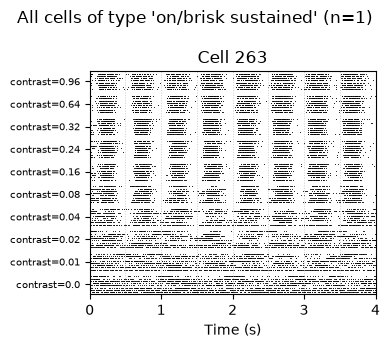

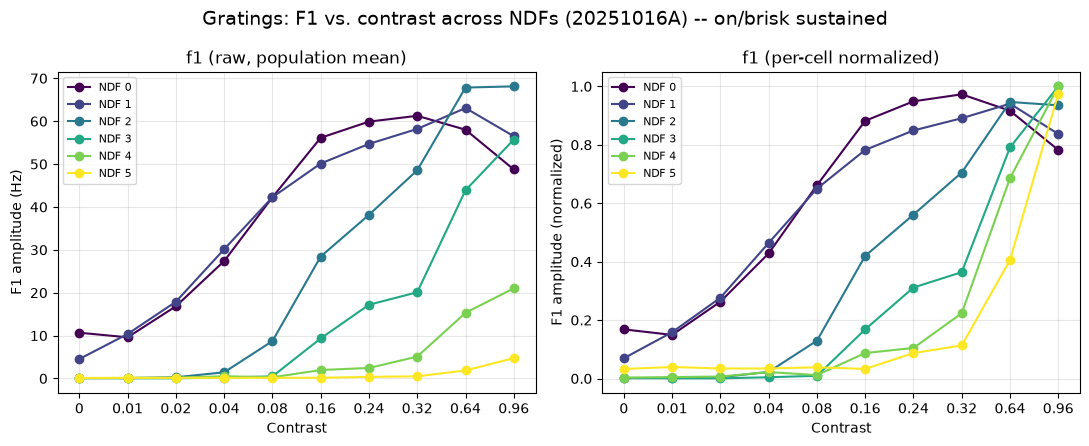

In [13]:
real = df_trials[~df_trials['cell_type'].isin(['Unknown', 'Unmatched'])]
EX_TYPE = real.drop_duplicates('cell_id')['cell_type'].value_counts().index[0]   # or e.g. 'on/brisk sustained'
per_cell = real[real['cell_type'] == EX_TYPE].groupby(['cell_id', 'contrast'])['f1'].mean().unstack()
EX_CELL = (per_cell.max(axis=1) - per_cell.min(axis=1)).idxmax()                 # or a cell_id
print(f'Example type: {EX_TYPE!r}, example cell: {EX_CELL}')

# Raster for one cell (same function as the contrast grating demo)
raster_example = ra.plot_rasters_for_cell_type(
    df_trials[df_trials['cell_id'] == EX_CELL], spike_times_by_cell, df_epochs,
    condition_key='contrast', selected_cell_type=EX_TYPE,
)

# F1 vs contrast for that type at every NDF (same call as the contrast grating demo; loads each NDF, takes a minute)
crf_example = ra.plot_crf_across_ndfs(
    EXP_NAME, contrast_search, GRATING_PROTOCOL, condition_key='contrast',
    analysis_chunk_name=ANALYSIS_CHUNK, corr_cutoff=CORR_CUTOFF,
    response_col='f1', typing_chunk=typing_chunk, cell_types=[EX_TYPE],
    baseline_condition_key='contrast', baseline_condition_value=0.0,
    title_prefix=f'Gratings: F1 vs. contrast across NDFs ({EXP_NAME})',
    show_sem=False, log_x=False, even_spacing=True,
)


## 5. Analysis: direction and orientation selectivity (DS/OS, GratingDSOS)

For each cell:
1. Pick the one spatial/temporal-frequency condition with the highest peak response.
2. Compute DSI and OSI from its tuning curve with `ra.compute_dsi_osi` (vector sum; OSI uses doubled angles, so it's blind to which way along an axis the grating moves).
3. Classify: **DS** if DSI > 0.3; otherwise **OS** if OSI > 0.3; and in both cases only if the peak rate is > 2 Hz. DS takes precedence, so a cell is never both.

**Decision to be aware of: mean rate vs F1.** The DS/OS demo (and the lab's `DS-OS.ipynb`) uses mean rate. Our standalone DS/OS master table uses F1, because mean rate undercounts OS cells: on 20251016A, 2.9% OS with mean rate vs 14.3% with F1. The cell below computes both so you can see the difference on your data.

**Also know:** older runs used 6 directions (20 reps) and newer ones 12 (5 reps), and 6 directions inflates the index. The spatial period changes DS yield. Preferred directions are in screen coordinates: fine within one retina, but don't pool them across retinas, since each retina sits at its own rotation on the rig.

In [14]:
DSOS_PROTOCOL = 'manookinlab.protocols.GratingDSOS'
DSI_T, OSI_T, MIN_HZ = 0.3, 0.3, 2.0

with ra.scrollable_prints():
    df_dsos, _, _, dsos_datafile, _ = ra.load_contrast_section(
        EXP_NAME, dsos_search, DSOS_PROTOCOL, condition_keys=['orientation', 'spatialFrequency', 'temporalFrequency'],
        analysis_chunk_name=ANALYSIS_CHUNK, corr_cutoff=CORR_CUTOFF, typing_chunk=typing_chunk,
    )

def classify(metric):
    tuning = df_dsos.groupby(['cell_id', 'spatialFrequency', 'temporalFrequency', 'orientation'])[list(dict.fromkeys([metric, 'mean_rate']))].mean().reset_index()
    rows = []
    for cell_id, g in tuning.groupby('cell_id'):
        best = max(g.groupby(['spatialFrequency', 'temporalFrequency']), key=lambda kv: kv[1]['mean_rate'].max())[1]
        res = ra.compute_dsi_osi(best['orientation'].values, best[metric].clip(lower=0).values)
        res.update(cell_id=cell_id, peak_rate=best['mean_rate'].max())
        rows.append(res)
    d = pd.DataFrame(rows)
    d['class'] = np.where((d.dsi > DSI_T) & (d.peak_rate > MIN_HZ), 'DS',
                 np.where((d.osi > OSI_T) & (d.peak_rate > MIN_HZ), 'OS', 'none'))
    return d

for metric in ['mean_rate', 'f1']:
    d = classify(metric)
    counts = d['class'].value_counts()
    print(f'{metric:>9}: {len(d)} cells | DS {counts.get("DS", 0)} ({100 * counts.get("DS", 0) / len(d):.1f}%) '
          f'| OS {counts.get("OS", 0)} ({100 * counts.get("OS", 0) / len(d):.1f}%)')

mean_rate: 449 cells | DS 46 (10.2%) | OS 6 (1.3%)
       f1: 449 cells | DS 44 (9.8%) | OS 51 (11.4%)


### Example: a DS cell's tuning curve

Mean rate for each direction of motion, at the cell's best spatial/temporal condition, on a polar plot (0° = rightward on the screen). The red arrow is the vector sum: it points in the preferred direction and its length is DSI × the peak rate, so a long arrow means strongly direction selective. The arrow won't always point exactly at the biggest dot: it's an average over every direction, so smaller responses in neighbouring directions pull it toward them, and on recordings with only 6 directions per condition (60° apart, the 2025 runs) it can sit up to ~30° from the sampled peak. By default the example is the most direction-selective DS cell that has a cell type and fires at least 5 Hz at its peak; set `EX_DS_CELL` to look at another.


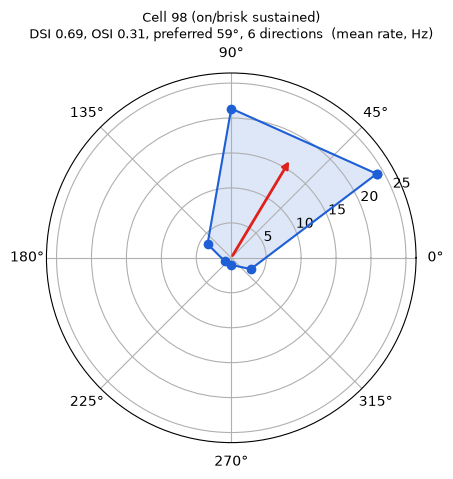

In [15]:
d_rate = classify('mean_rate')
d_rate['cell_type'] = d_rate['cell_id'].map(df_dsos.drop_duplicates('cell_id').set_index('cell_id')['cell_type'])
# Example: a DS cell that has a cell type (EI-matched) and responds well (peak >= 5 Hz), highest DSI first.
ds_cells = d_rate[(d_rate['class'] == 'DS') & ~d_rate['cell_type'].isin(['Unknown', 'Unmatched'])]
strong = ds_cells[ds_cells['peak_rate'] >= 5]
pool = strong if len(strong) else (ds_cells if len(ds_cells) else d_rate[d_rate['class'] == 'DS'])
EX_DS_CELL = pool.sort_values('dsi', ascending=False)['cell_id'].iloc[0]   # or a cell_id

tun = (df_dsos[df_dsos['cell_id'] == EX_DS_CELL]
       .groupby(['spatialFrequency', 'temporalFrequency', 'orientation'])['mean_rate'].mean().reset_index())
(best_sf, best_tf), cur = max(tun.groupby(['spatialFrequency', 'temporalFrequency']), key=lambda kv: kv[1]['mean_rate'].max())
cur = cur.sort_values('orientation')
res = d_rate.set_index('cell_id').loc[EX_DS_CELL]
ex_type = res['cell_type']

th = np.deg2rad(np.r_[cur['orientation'].values, cur['orientation'].values[0]])
r = np.r_[cur['mean_rate'].values, cur['mean_rate'].values[0]]
fig = plt.figure(figsize=(4.8, 4.8)); ax = fig.add_subplot(projection='polar')
ax.plot(th, r, 'o-', color='#1f5fd6'); ax.fill(th, r, color='#1f5fd6', alpha=0.15)
ax.set_rlim(0, r.max() * 1.1)        # radius must start at 0, or short vectors get drawn through the centre to the wrong side
ax.annotate('', xy=(np.deg2rad(res['preferred_direction_deg']), r.max() * res['dsi']), xytext=(0, 0),
            arrowprops=dict(arrowstyle='-|>', color='#e0201b', lw=2))
ax.set_title(f'Cell {EX_DS_CELL} ({ex_type})\nDSI {res["dsi"]:.2f}, OSI {res["osi"]:.2f}, '
             f'preferred {res["preferred_direction_deg"]:.0f}°, {len(cur)} directions  (mean rate, Hz)', fontsize=9)
plt.show()


## 6. Saving figures and data

- **Easiest:** the `SAVE_CELLS` cell at the top of every notebook. Set it to `'all'` or to a list of cell numbers, and every figure those cells make is saved to `figures/` as `.svg` + `.pdf`, with text still editable in Illustrator. Files are named after the cell and the figure title, e.g. `cell12_1_off-brisk-sustained-RF-portraits.svg`. Cell numbers are the `[n]` Jupyter shows, which only count 1, 2, 3… from the top after **Kernel → Restart & Run All**.
- **One figure by hand:** `ra.save_figure(fig, 'folder/name')`.
- **Numbers for Igor/MATLAB/journals:** save the table the plot was made from, e.g. `df_trials.to_csv(...)`, one row per cell and trial. `ra.export_figure_data(fig, ...)` also exists; it's clean for simple line plots but messy for box plots.

In [16]:
OUT = f'figures/{EXP_NAME}'
fig_crf = crf_example[EX_TYPE]                 # plot_crf_across_ndfs returns {cell_type: figure}
ra.save_figure(fig_crf, f'{OUT}/crf_across_ndfs')
ra.export_figure_data(fig_crf, f'{OUT}/crf_across_ndfs')

Saved crf_across_ndfs.svg, crf_across_ndfs.pdf, crf_across_ndfs.png
Saved crf_across_ndfs.csv (24 columns)


'figures/20251016A/crf_across_ndfs.csv'

## Where to go next
- `1_database_demo`: search the database and plot mosaics across experiments.
- `2_data_quality_demo`: QC a chunk (RF mosaics, contours, portraits + timecourses, RF size, EI footprints across NDFs).
- `3_contrast_grating_demo`, `5_flash_demo`, `6_spot_demo`: contrast-response curves per stimulus, across NDFs.
- `4_grating_dsos_demo`: DS/OS for one experiment with polar/raster plots.
- `7_correlated_spiking_demo`: cross-correlations across light levels.
- `8_genotype_comparison_demo`: compare genotypes across experiments.